In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)


In [3]:
# 1. LOAD & PREPARE DATA
# ============================================================================
df = pd.read_csv('ASA All PGA Raw Data - Tourn Level.csv')

sg_components = ['sg_ott', 'sg_app', 'sg_arg', 'sg_putt']
df_model = df[sg_components + ['total_DKP']].dropna()

print(f"Observations used in model: {len(df_model)}")

Observations used in model: 29180


In [4]:
# 2. STANDARDIZE PREDICTORS (z-scores)
# ============================================================================
# Standardizing puts all four SG components on the same scale, so coefficients
# can be directly compared to identify the "strongest" predictor.
df_z = df_model.copy()
for col in sg_components:
    df_z[col] = (df_model[col] - df_model[col].mean()) / df_model[col].std()

X = df_z[sg_components]
X = sm.add_constant(X)
y = df_z['total_DKP']

In [5]:
# 3. RUN OLS REGRESSION
# ============================================================================
model = sm.OLS(y, X).fit()

print("\n" + "="*80)
print("REGRESSION RESULTS: total_DKP ~ sg_ott + sg_app + sg_arg + sg_putt")
print("="*80)
print(model.summary())


REGRESSION RESULTS: total_DKP ~ sg_ott + sg_app + sg_arg + sg_putt
                            OLS Regression Results                            
Dep. Variable:              total_DKP   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     9470.
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:07:43   Log-Likelihood:            -1.2742e+05
No. Observations:               29180   AIC:                         2.548e+05
Df Residuals:                   29175   BIC:                         2.549e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

In [6]:
# 4. EXTRACT STANDARDIZED COEFFICIENTS FOR COMPARISON
# ============================================================================
coef_df = pd.DataFrame({
    'component': sg_components,
    'coefficient': model.params[sg_components].values,
    'std_err': model.bse[sg_components].values,
    'p_value': model.pvalues[sg_components].values
})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print("\n" + "="*80)
print("STANDARDIZED COEFFICIENTS RANKED (Strongest Predictor First)")
print("="*80)
print(coef_df[['component', 'coefficient', 'std_err', 'p_value']].to_string(index=False))



STANDARDIZED COEFFICIENTS RANKED (Strongest Predictor First)
component  coefficient  std_err  p_value
  sg_putt    13.257807 0.111704      0.0
   sg_app    12.287335 0.112441      0.0
   sg_ott     8.250581 0.112401      0.0
   sg_arg     7.204179 0.111754      0.0


In [7]:
# 5. CHECK MULTICOLLINEARITY (VIF)
# ============================================================================
vif_df = pd.DataFrame()
vif_df['component'] = sg_components
vif_df['VIF'] = [variance_inflation_factor(df_model[sg_components].values, i) 
                  for i in range(len(sg_components))]

print("\n" + "="*80)
print("VARIANCE INFLATION FACTOR (Multicollinearity Check)")
print("="*80)
print(vif_df.to_string(index=False))
print("\nNote: VIF < 5 generally indicates multicollinearity is not a serious concern.")


VARIANCE INFLATION FACTOR (Multicollinearity Check)
component      VIF
   sg_ott 1.015206
   sg_app 1.016546
   sg_arg 1.003506
  sg_putt 1.001914

Note: VIF < 5 generally indicates multicollinearity is not a serious concern.


In [8]:
# 6. MODEL FIT SUMMARY
# ============================================================================
print("\n" + "="*80)
print("MODEL FIT SUMMARY")
print("="*80)
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"F-statistic: {model.fvalue:.2f}, p-value: {model.f_pvalue:.2e}")
print(f"\nInterpretation: The four strokes-gained components together explain "
      f"{model.rsquared*100:.1f}% of variation in total_DKP.")


MODEL FIT SUMMARY
R-squared: 0.5649
Adjusted R-squared: 0.5649
F-statistic: 9470.37, p-value: 0.00e+00

Interpretation: The four strokes-gained components together explain 56.5% of variation in total_DKP.


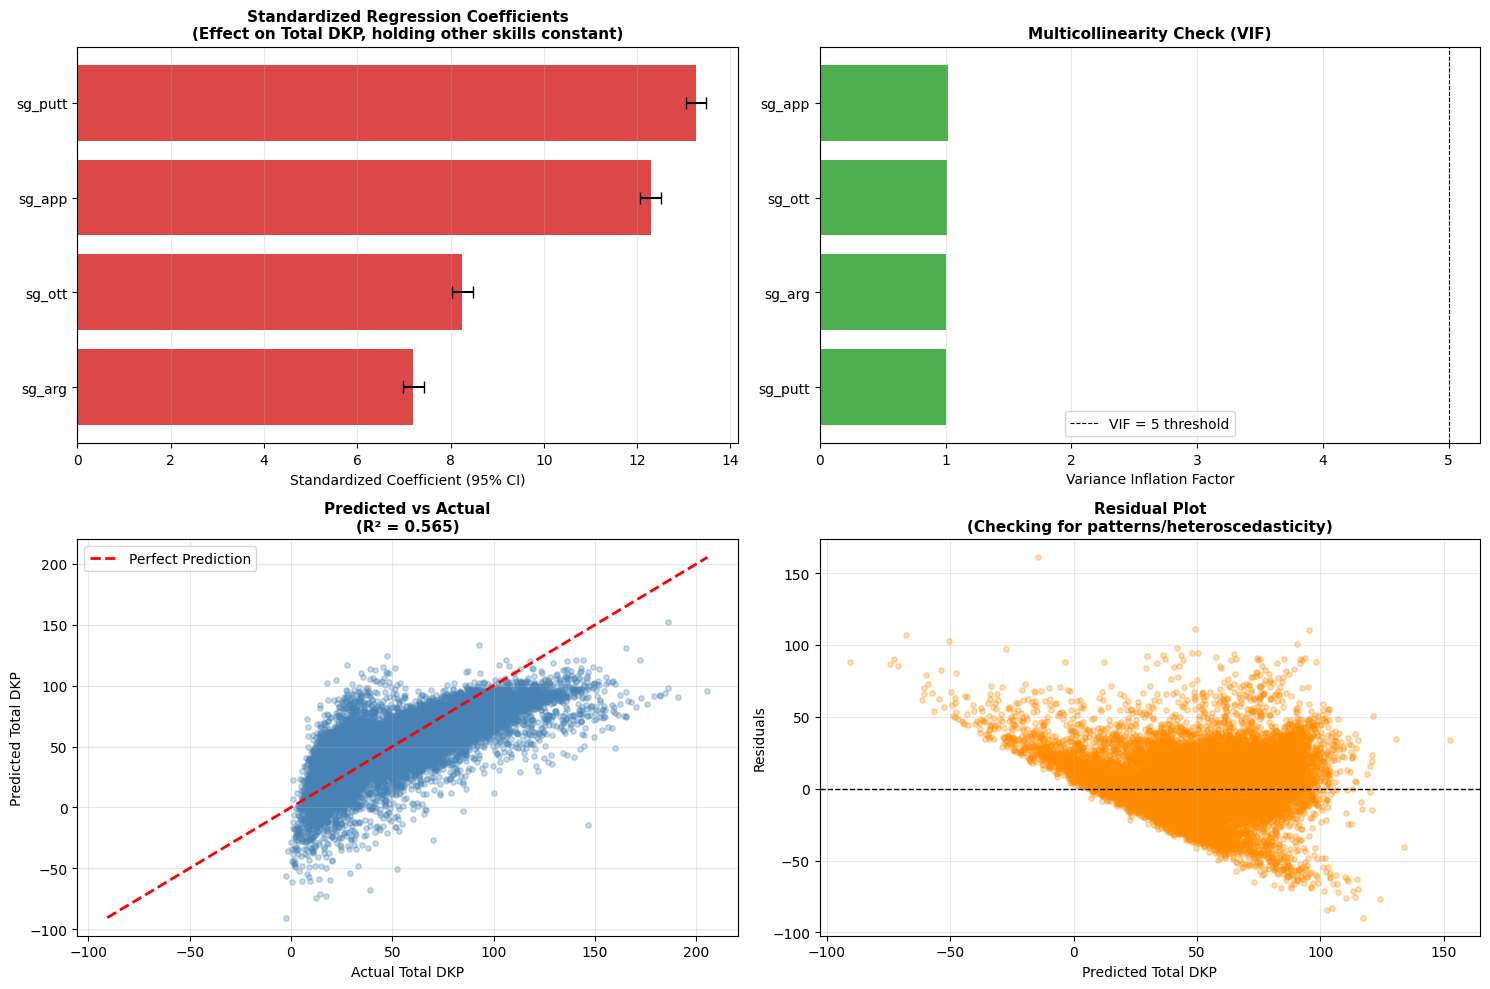

In [9]:
# 7. VISUALIZATIONS
# ============================================================================
fig = plt.figure(figsize=(15, 10))

# --- Plot 1: Standardized Coefficient Plot (the key visual) ---
ax1 = plt.subplot(2, 2, 1)
plot_df = coef_df.sort_values('coefficient')
colors = ['#d62728' if p < 0.05 else '#aaaaaa' for p in plot_df['p_value']]
bars = ax1.barh(plot_df['component'], plot_df['coefficient'], 
                 xerr=plot_df['std_err']*1.96, color=colors, alpha=0.85, capsize=4)
ax1.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_xlabel('Standardized Coefficient (95% CI)')
ax1.set_title('Standardized Regression Coefficients\n(Effect on Total DKP, holding other skills constant)', 
              fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# --- Plot 2: VIF Bar Chart ---
ax2 = plt.subplot(2, 2, 2)
vif_sorted = vif_df.sort_values('VIF')
colors_vif = ['#2ca02c' if v < 5 else '#d62728' for v in vif_sorted['VIF']]
ax2.barh(vif_sorted['component'], vif_sorted['VIF'], color=colors_vif, alpha=0.85)
ax2.axvline(5, color='black', linestyle='--', linewidth=0.8, label='VIF = 5 threshold')
ax2.set_xlabel('Variance Inflation Factor')
ax2.set_title('Multicollinearity Check (VIF)', fontsize=11, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='x')

# --- Plot 3: Predicted vs Actual ---
ax3 = plt.subplot(2, 2, 3)
predicted = model.predict(X)
ax3.scatter(y, predicted, alpha=0.3, s=15, color='steelblue')
lims = [min(y.min(), predicted.min()), max(y.max(), predicted.max())]
ax3.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
ax3.set_xlabel('Actual Total DKP')
ax3.set_ylabel('Predicted Total DKP')
ax3.set_title(f'Predicted vs Actual\n(R² = {model.rsquared:.3f})', fontsize=11, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Residuals Plot ---
ax4 = plt.subplot(2, 2, 4)
residuals = model.resid
ax4.scatter(predicted, residuals, alpha=0.3, s=15, color='darkorange')
ax4.axhline(0, color='black', linestyle='--', linewidth=1)
ax4.set_xlabel('Predicted Total DKP')
ax4.set_ylabel('Residuals')
ax4.set_title('Residual Plot\n(Checking for patterns/heteroscedasticity)', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# ============================================================================
# 8. SUMMARY FOR WRITE-UP
# ============================================================================
print("\n" + "="*80)
print("SUMMARY FOR WRITE-UP")
print("="*80)
top = coef_df.iloc[0]
print(f"""
Strongest predictor (by standardized coefficient): {top['component']}
  Coefficient: {top['coefficient']:.3f} (p = {top['p_value']:.2e})

Full ranking:
{coef_df[['component', 'coefficient', 'p_value']].to_string(index=False)}

Model explains {model.rsquared*100:.1f}% of variance in earnings proxy (R² = {model.rsquared:.3f}).
All VIF values are {'below 5, indicating multicollinearity is not a major concern.' if vif_df['VIF'].max() < 5 else 'flagged — check VIF table above for details.'}
""")


SUMMARY FOR WRITE-UP

Strongest predictor (by standardized coefficient): sg_putt
  Coefficient: 13.258 (p = 0.00e+00)

Full ranking:
component  coefficient  p_value
  sg_putt    13.257807      0.0
   sg_app    12.287335      0.0
   sg_ott     8.250581      0.0
   sg_arg     7.204179      0.0

Model explains 56.5% of variance in earnings proxy (R² = 0.565).
All VIF values are below 5, indicating multicollinearity is not a major concern.

